In [1]:
import numpy as np
import pandas as pd
from scipy import  stats
import seaborn as sns

In [2]:
df = pd.read_csv("fichier_netoyee.csv")

In [3]:
df.head()

,id_client,nom,age,type_contrat,date_contrat,region,prime,nb_sinistres,montant_sinistres
0,100,Client_100,35.000000,auto,2022-04-23,Savanes,324.63,3,810.05
1,298,Client_298,57.000000,moto,2020-04-05,Plateaux,172.37,0,0.00
2,90,Client_90,65.000000,habitation,2020-08-03,Plateaux,179.38,1,612.00
3,31,Client_31,45.692833,auto,2021-02-05,Savanes,245.67,0,0.00
4,236,Client_236,69.000000,habitation,2021-12-23,Maritime,130.21,1,567.57


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_client          305 non-null    int64  
 1   nom                305 non-null    object 
 2   age                305 non-null    float64
 3   type_contrat       305 non-null    object 
 4   date_contrat       305 non-null    object 
 5   region             305 non-null    object 
 6   prime              305 non-null    float64
 7   nb_sinistres       305 non-null    int64  
 8   montant_sinistres  305 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.6+ KB


In [5]:
# df["date_contrat"].unique() pas de probcleme

In [6]:
df.describe().round(2)

,id_client,age,prime,nb_sinistres,montant_sinistres
count,305.00,305.00,305.00,305.00,305.00
mean,150.72,45.69,243.64,0.51,390.39
std,86.21,16.13,95.74,0.78,707.05
min,1.00,18.00,50.75,0.00,0.00
25%,77.00,32.00,159.44,0.00,0.00
50%,151.00,45.69,249.16,0.00,0.00
75%,224.00,58.00,306.51,1.00,616.08
max,300.00,74.00,516.20,4.00,5424.83


In [7]:
# correction du type de donne de l'age
df["age"] = df["age"].astype(int)

In [8]:
np.dtype(df["age"])# Correctgiocn fait avec succes

dtype('int64')

In [9]:
df.loc[df["nb_sinistres"] == 0, ].shape[0]

192

In [10]:
df.shape

(305, 9)

In [11]:
df = df.drop(df[df["nb_sinistres"] ==0].index)

In [12]:
df.shape

(113, 9)

In [13]:
# plus de nombre sinistre egadle a 0

In [14]:
df.describe().round(2)

,id_client,age,prime,nb_sinistres,montant_sinistres
count,113.00,113.00,113.00,113.00,113.00
mean,151.35,38.72,274.46,1.38,1053.72
std,82.83,15.77,105.81,0.66,807.29
min,3.00,18.00,83.74,1.00,246.24
25%,83.00,24.00,183.36,1.00,558.44
50%,151.00,39.00,284.36,1.00,914.50
75%,219.00,49.00,332.82,2.00,1219.49
max,292.00,74.00,516.20,4.00,5424.83


In [15]:
df.head()

,id_client,nom,age,type_contrat,date_contrat,region,prime,nb_sinistres,montant_sinistres
0,100,Client_100,35,auto,2022-04-23,Savanes,324.63,3,810.05
2,90,Client_90,65,habitation,2020-08-03,Plateaux,179.38,1,612.00
4,236,Client_236,69,habitation,2021-12-23,Maritime,130.21,1,567.57
12,180,Client_180,32,habitation,2024-08-16,Kara,124.76,1,1169.70
15,135,Client_135,29,auto,2024-01-23,Savanes,369.51,1,999.47


## Tendance centrale et dispersion 

In [16]:
float(df["prime"].mean().round(2))

274.46

## Loi normale


Cette loi consiste a gerer ou a verifier une distribution 

In [17]:
loi_normale = stats.norm.pdf(x= 30, loc=df["age"].mean(), scale = df["age"].std())
print(f"La loi normale de distrubution de la moyenne de l'age et de l'ecartype : {loi_normale.round(2)}")

La loi normale de distrubution de la moyenne de l'age et de l'ecartype : 0.02


## Loi de poisson  

cette loi est utile pour modeliser un nombre d'evenement

In [18]:
loi_poisson = stats.poisson.pmf(k = 2, mu = df["nb_sinistres"].mean())
float(loi_poisson.round(2))

0.24

## Test de correlation avec p_value

<Axes: xlabel='age', ylabel='Count'>

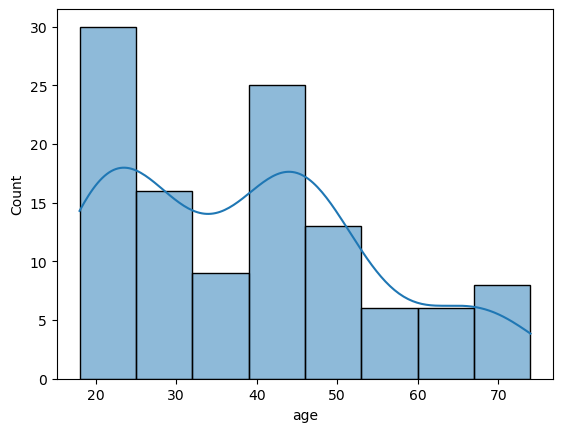

In [20]:
sns.histplot(df["age"],kde= True)

In [24]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [25]:
dataset = sns.get_dataset_names()
dataset

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [28]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

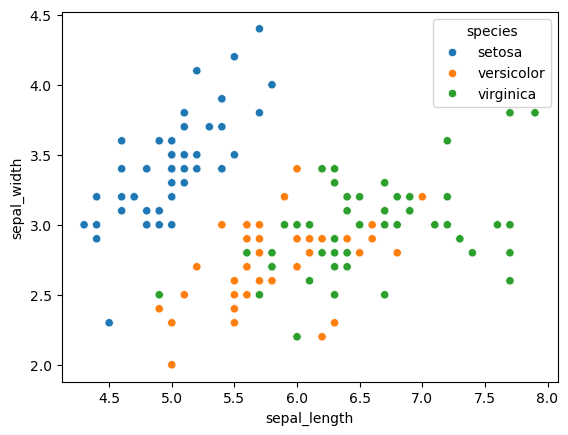

In [30]:
sns.scatterplot(data = iris, x= "sepal_length", y = "sepal_width", hue = "species")

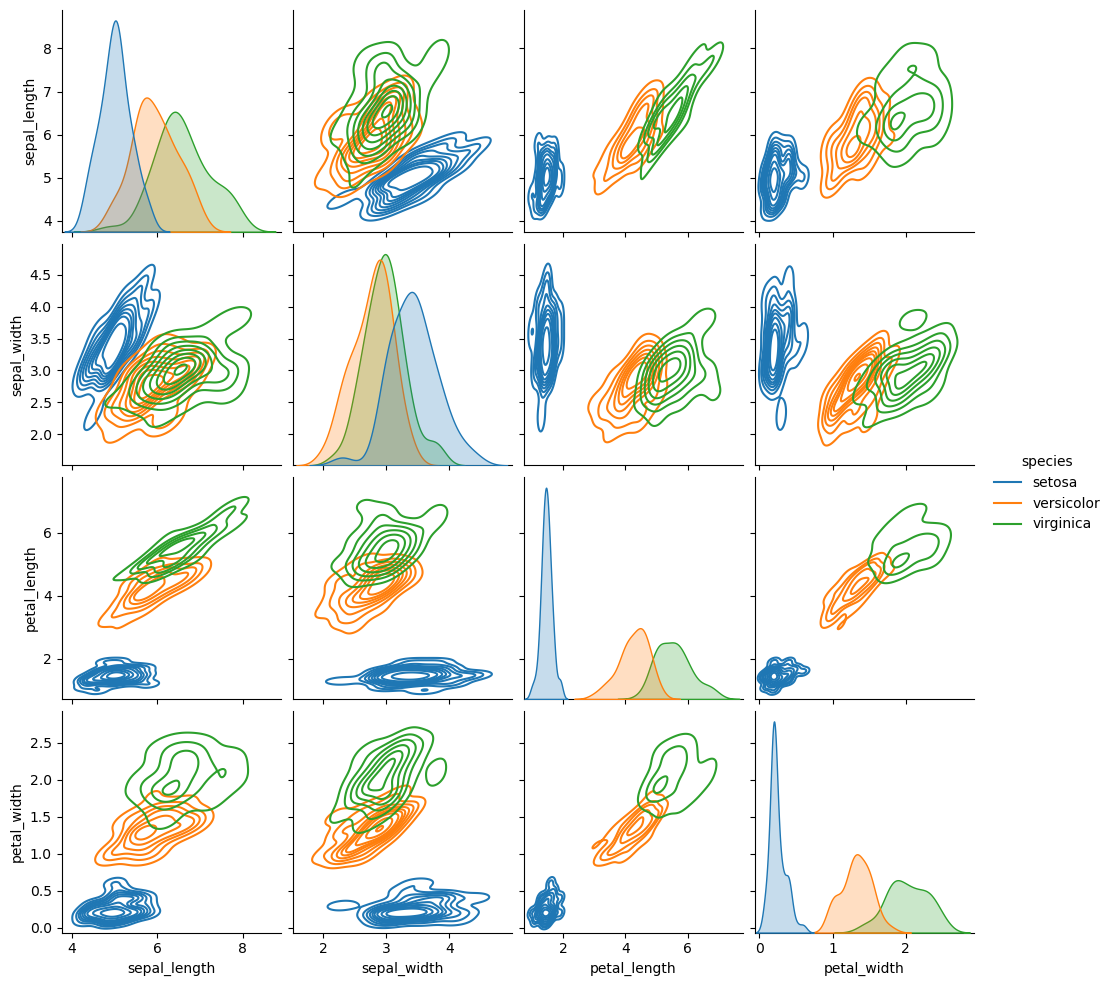

In [53]:
sns.pairplot(iris, hue = "species", kind = "kde") 

In [34]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [37]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

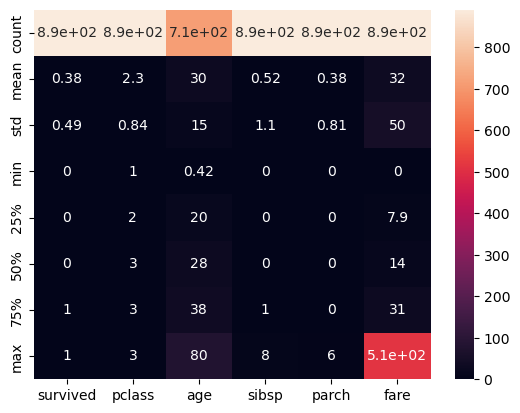

In [39]:
sns.heatmap(titanic.describe(), annot = True)

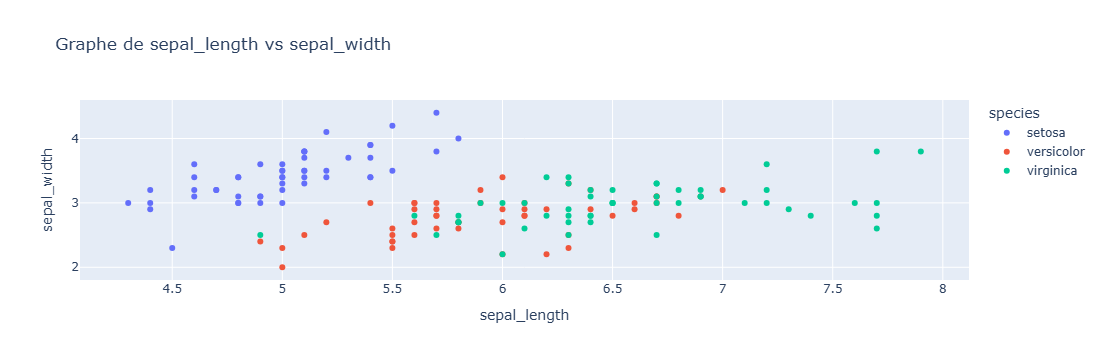

In [50]:
import plotly.express as px

fig = px.scatter(
    iris,
    x="sepal_length",
    y="sepal_width",
    color="species",
    title="Graphe de sepal_length vs sepal_width"
)
fig.show()

In [41]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [54]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [56]:
iris.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


<Axes: xlabel='sepal_length', ylabel='petal_length'>

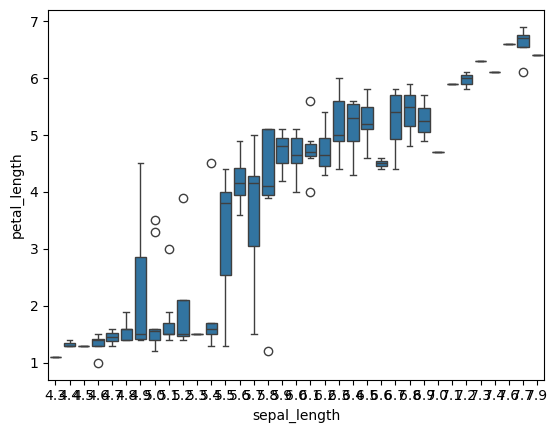

In [58]:
sns.boxplot(data = iris, x = "sepal_length", y="petal_length")